# Modeling

## 1. Imports

In [1]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 2. Obtener data

In [2]:
df = pd.read_csv('../data/processed/train_processed.csv')

In [3]:
df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
0,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325
1,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475
2,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125
3,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150
4,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350


## 3. Separar data

Ahora separaremos la información e intentaremos predecir las 10 últimas semanas.

In [4]:
n_semanas_test = 10

# El "-" para que cuente hacia atrás
train = df.iloc[:-n_semanas_test]

test = df.iloc[-n_semanas_test:]

In [5]:
train.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
0,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325
1,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475
2,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125
3,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150
4,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350


In [6]:
test.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
195,2018-10-28,21535.270,13270.8182,16509.8310,21535.5940,12296.0620,15903.07630
196,2018-11-04,29017.467,21535.2700,13270.8182,16509.8310,21535.5940,18212.87830
197,2018-11-11,20015.550,29017.4670,21535.2700,13270.8182,16509.8310,20083.34655
198,2018-11-18,30572.447,20015.5500,29017.4670,21535.2700,13270.8182,20959.77630
199,2018-11-25,22212.769,30572.4470,20015.5500,29017.4670,21535.2700,25285.18350


Ahora separamos X e y

In [7]:
X_train = train.drop(columns=['Order Date', 'Sales'])
y_train = train['Sales']

X_test = test.drop(columns=['Order Date', 'Sales'])
y_test = test['Sales']

## 4. Modeling

### 4.1 Naive forecast

El naive forecast, hace referencia a simplemente predecir lo que se vendió la semana pasada.

Es la forma más simple de hacer la predicción, no aprende patrones, estacionalidad ni nada. Por lo que cualquier modelo más sofisticado debería de ser mejor que este naive forecast.

Aquí el 'Lag_1' son las ventas de la semana pasada, generaremos una predicción ingenua.

In [8]:
y_pred_naive = X_test['Lag_1']

naive_mae = mean_absolute_error(y_test, y_pred_naive)
naive_rmse = root_mean_squared_error(y_test, y_pred_naive)

print(f'Naive MAE: {naive_mae:.3f}\nNaive RMSE: {naive_rmse:.3f}')

Naive MAE: 9406.775
Naive RMSE: 9830.573


### 4.3 Escalar data

Probaremos modelos como LinearRegression que necesitan datos escalados para no darle una importancia a valores muy grandes.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4.4 Pruebas con distintos modelos

Modelos a probar

In [10]:
models = {
    'LinearRegression': LinearRegression(),
    'XGBRegressor': XGBRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'LGBMRegressor': LGBMRegressor(random_state=42, verbose=-1)
}

Evaluar modelos con MAE y RMSE

Primero crearemos un diccionario para almacenar las predicciones de cada modelo. Y una lista para guardar en forma de diccionario cada resultado obtenido. Además incluimos primero los resultados de la predicción ingenua.

In [11]:
predictions = {}

results = [
    {'model': 'Naive', 'MAE': naive_mae, 'RMSE': naive_rmse}
]

In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    # Guardar cada predicción en un diccionario con nombre de key el modelo
    predictions[name] = y_pred

    # Guardar mae y rmse para cada modelo
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse})

    print(f'Modelo: {name}\nMAE: {mae}\nRMSE: {rmse}\n')


# Convertir el listado de results en un DataFrame
results = pd.DataFrame(results)

Modelo: LinearRegression
MAE: 7869.618174116445
RMSE: 9660.678453344795

Modelo: XGBRegressor
MAE: 6550.199137031251
RMSE: 8996.267008840174

Modelo: RandomForestRegressor
MAE: 7764.532501299994
RMSE: 9153.056803694975

Modelo: LGBMRegressor
MAE: 7030.404418523484
RMSE: 8057.876011034916



Graficar predicciones

In [13]:
predictions

{'LinearRegression': array([12595.40671211, 14106.55267578, 17852.46669098, 17023.41405483,
        18131.3769933 , 17862.58471027, 20103.43432815, 18812.30404515,
        13280.93051605, 13174.7194225 ]),
 'XGBRegressor': array([15714.903, 17687.951, 19842.871, 26233.725, 13138.099, 13711.364,
        18027.25 , 10788.129, 16475.436,  9978.713], dtype=float32),
 'RandomForestRegressor': array([14327.659813, 15882.869641, 16388.802549, 21758.716623,
        16206.67508 , 16395.564898, 16435.73486 , 16171.982458,
        12536.597122, 12608.800659]),
 'LGBMRegressor': array([12595.17190425, 20495.53134277, 15977.63513017, 21008.33354919,
        16174.49575236, 20133.8627965 , 19886.27555563, 19886.27555563,
        14915.70126341, 12409.98787611])}

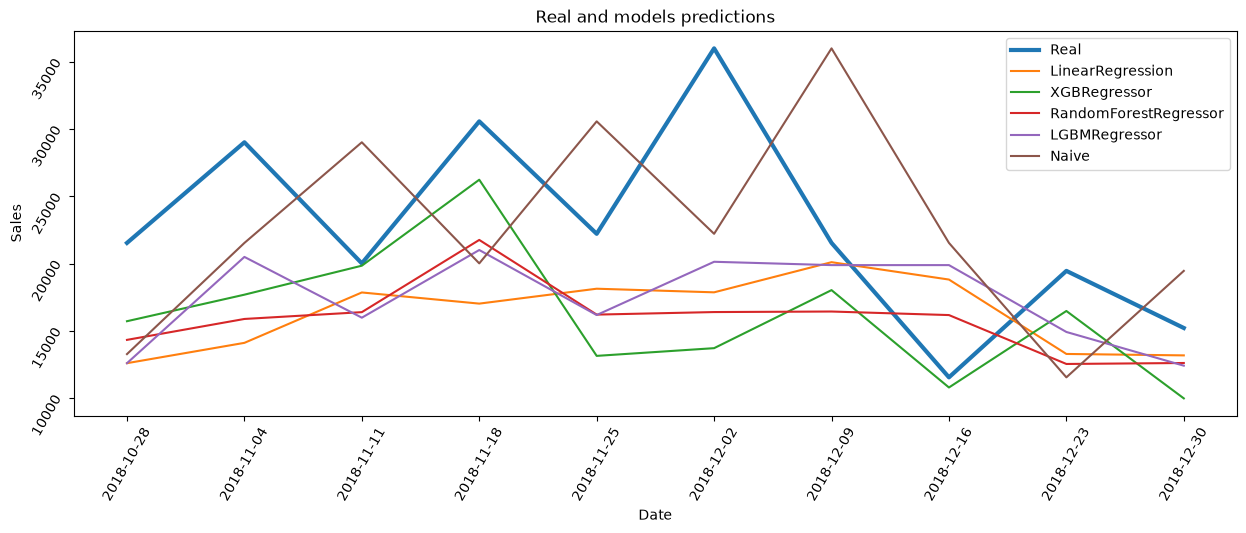

In [14]:
plt.figure(figsize=(15, 5))

# Datos reales
plt.plot(
    test['Order Date'],
    test['Sales'],
    linewidth=3,
    label='Real'
)

# Datos predichos
for model, preds in predictions.items():
    plt.plot(
        test['Order Date'],
        preds,
        label=model
    )

# Datos ingenuos
plt.plot(
    test['Order Date'],
    y_pred_naive,
    label='Naive'
)

plt.tick_params(rotation=60)

plt.title('Real and models predictions')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.show()

Graficar resultados MAE/RMSE

In [15]:
results

,model,MAE,RMSE
0,Naive,9406.775400,9830.572512
1,LinearRegression,7869.618174,9660.678453
2,XGBRegressor,6550.199137,8996.267009
3,RandomForestRegressor,7764.532501,9153.056804
4,LGBMRegressor,7030.404419,8057.876011


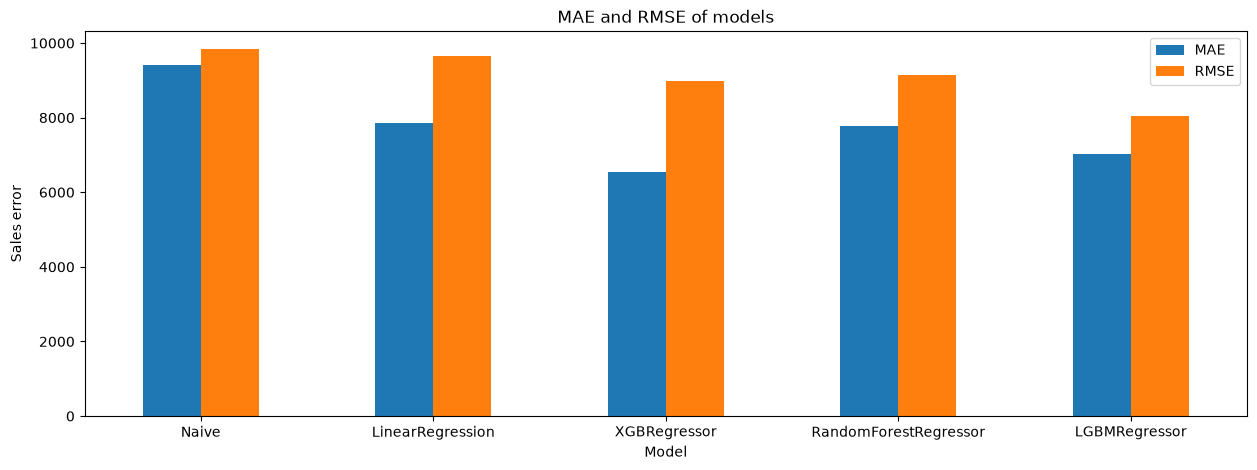

In [18]:
results.plot(
    kind='bar',
    x='model',
    y=['MAE', 'RMSE'],
    figsize=(15, 5)
)

plt.xlabel('Model')
plt.ylabel('Sales error')

plt.title('MAE and RMSE of models')

plt.tick_params(rotation=0)

plt.show()